# 04 -- 商品结构分析

---

## 业务背景

"哪些品类在支撑我们的 GMV？" "哪些商品是流量款、哪些是利润款？" "用户买了 A 还会买 B 吗？"

商品分析的核心目的不是做一个好看的品类排行榜，而是回答三个运营问题：
1. **资源怎么分配？** 哪些品类值得投入更多采购 / 营销资源？
2. **商品怎么组合？** 该怎么搭配推荐，提升连带率？
3. **库存怎么管理？** 哪些是滞销品，该清仓还是捆绑销售？

## 1. 环境与数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

txn = pd.read_parquet('../output/transactions_wide.parquet')
products = pd.read_parquet('../output/products_clean.parquet')

completed = txn[txn['status'] == 'completed'].copy()
print(f"已完成订单: {len(completed):,}")
print(f"商品数: {products['product_id'].nunique():,}")
print(f"品类数: {products['category'].nunique():,}")

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


已完成订单: 68,700
商品数: 1,000
品类数: 15


## 2. 品类销售贡献分析

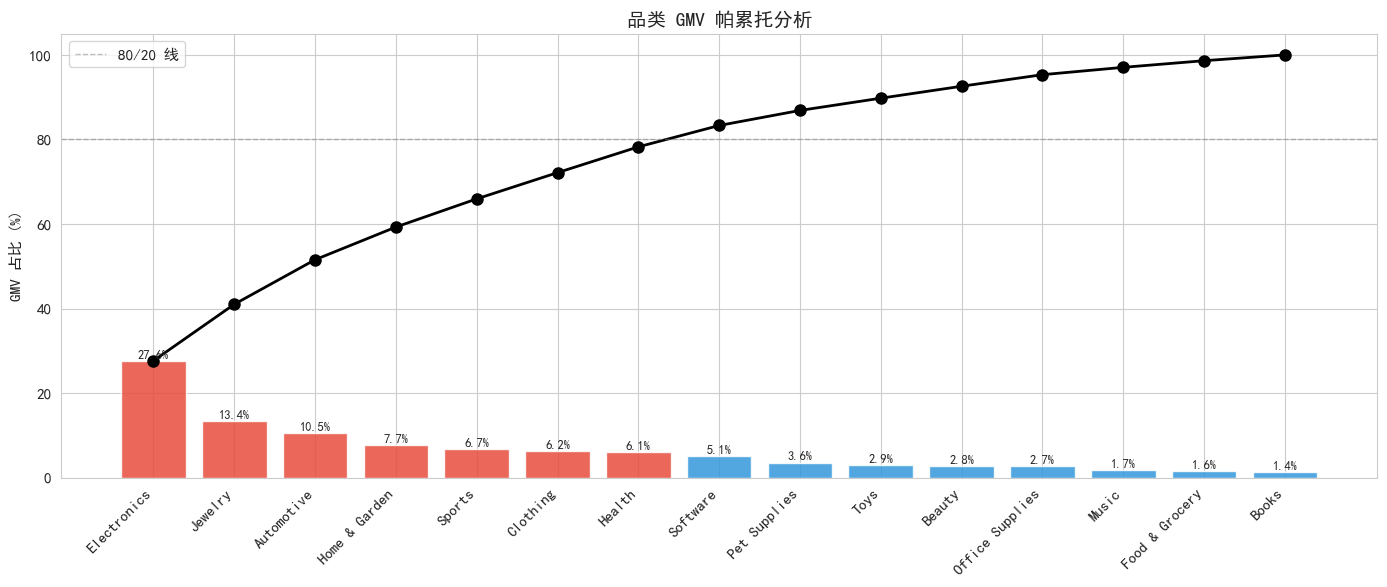

=== ABC 分层结果 ===
贡献前 80% GMV 的品类 (7 个): ['Electronics', 'Jewelry', 'Automotive', 'Home & Garden', 'Sports', 'Clothing', 'Health']
贡献后 20% GMV 的品类 (8 个): ['Software', 'Pet Supplies', 'Toys', 'Beauty', 'Office Supplies', 'Music', 'Food & Grocery', 'Books']

Top 3 品类贡献: 51.5% 的 GMV


In [2]:
# 按品类汇总
cat_stats = completed.groupby('category').agg(
    gmv=('total_amount', 'sum'),
    orders=('transaction_id', 'nunique'),
    quantity=('quantity', 'sum'),
    unique_products=('product_id', 'nunique'),
    unique_customers=('customer_id', 'nunique'),
    avg_price=('unit_price', 'mean')
).sort_values('gmv', ascending=False)
cat_stats['gmv_share'] = cat_stats['gmv'] / cat_stats['gmv'].sum() * 100
cat_stats['gmv_share_cum'] = cat_stats['gmv_share'].cumsum()
cat_stats['aov'] = cat_stats['gmv'] / cat_stats['orders']

fig, ax = plt.subplots(figsize=(14, 6))

# 帕累托图
colors = ['#e74c3c' if s <= 80 else '#3498db' for s in cat_stats['gmv_share_cum']]
ax.bar(range(len(cat_stats)), cat_stats['gmv_share'], color=colors, alpha=0.85)
ax.plot(range(len(cat_stats)), cat_stats['gmv_share_cum'], 'ko-', linewidth=2, markersize=8)
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='80/20 线')
ax.set_xticks(range(len(cat_stats)))
ax.set_xticklabels(cat_stats.index, rotation=45, ha='right')
ax.set_title('品类 GMV 帕累托分析', fontsize=14, fontweight='bold')
ax.set_ylabel('GMV 占比 (%)')
ax.legend()

# 标注每个柱子
for i, (share, cum) in enumerate(zip(cat_stats['gmv_share'], cat_stats['gmv_share_cum'])):
    ax.text(i, share + 0.5, f'{share:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 前 80% 和后 20% 的品类
top_80 = cat_stats[cat_stats['gmv_share_cum'] <= 80]
bottom_20 = cat_stats[cat_stats['gmv_share_cum'] > 80]
print(f"=== ABC 分层结果 ===")
print(f"贡献前 80% GMV 的品类 ({len(top_80)} 个): {list(top_80.index)}")
print(f"贡献后 20% GMV 的品类 ({len(bottom_20)} 个): {list(bottom_20.index)}")
print(f"\nTop 3 品类贡献: {cat_stats['gmv_share'].iloc[:3].sum():.1f}% 的 GMV")

**业务解读：**
- **A 类（前 80%）**：核心品类，保证库存深度，持续优化供应链成本
- **B 类（80-95%）**：成长品类，测试新的营销策略，看能否推入 A 类
- **C 类（后 5%）**：长尾品类或候选淘汰品类，评估是否值得继续维持 SKU


## 3. 品类矩阵

把每个品类放进四个象限：高销量高价、高销量低价、低销量高价、低销量低价。

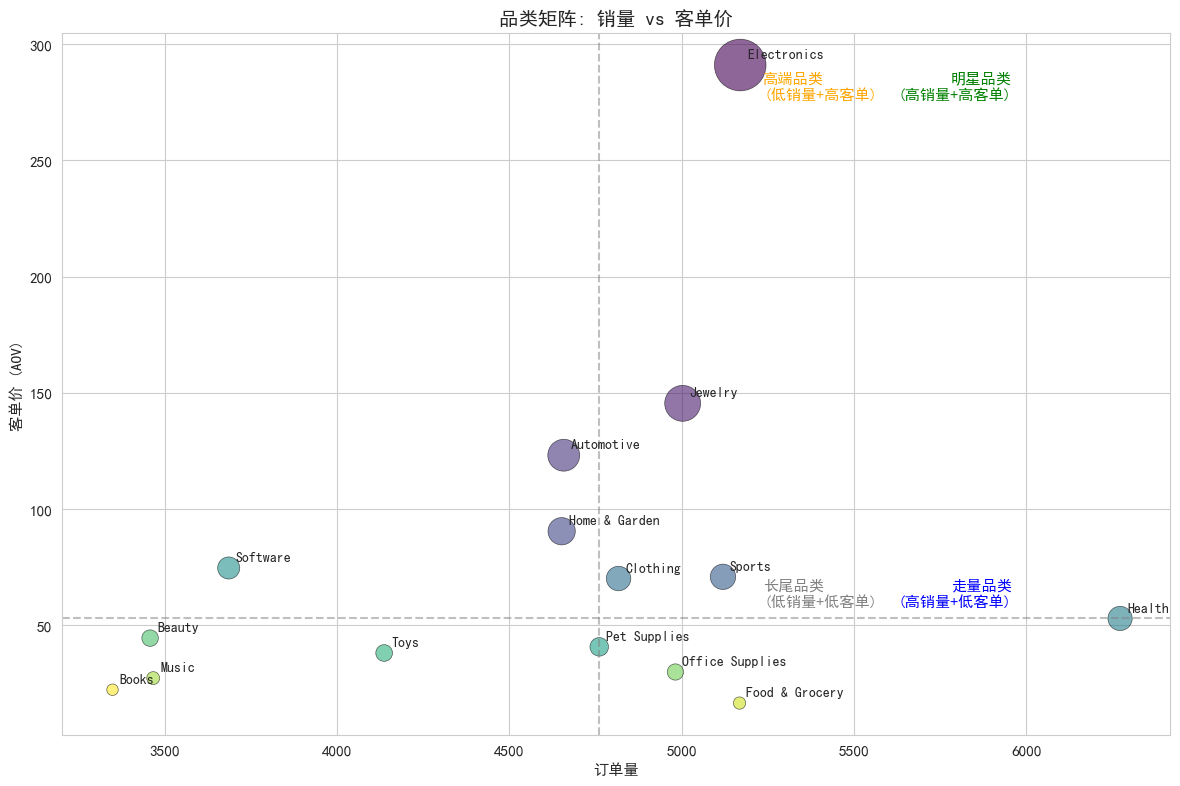

In [3]:
# 按品类做矩阵
fig, ax = plt.subplots(figsize=(12, 8))

x = cat_stats['orders']
y = cat_stats['aov']
avg_x = x.median()
avg_y = y.median()

# 散点 + 气泡大小表示 GMV 占比
scatter = ax.scatter(x, y, s=cat_stats['gmv_share'] * 50, alpha=0.6,
                     c=range(len(cat_stats)), cmap='viridis', edgecolors='black', linewidth=0.5)

# 标注
for name, xi, yi in zip(cat_stats.index, x, y):
    ax.annotate(name, (xi, yi), textcoords="offset points", xytext=(5, 5),
                fontsize=10, fontweight='bold')

# 四象限线
ax.axvline(x=avg_x, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=avg_y, color='gray', linestyle='--', alpha=0.5)

# 象限标签
x_max = x.max()
y_max = y.max()
ax.text(x_max * 0.95, y_max * 0.95, '明星品类\n(高销量+高客单)', ha='right', fontsize=11, color='green', fontweight='bold')
ax.text(avg_x * 1.1, y_max * 0.95, '高端品类\n(低销量+高客单)', ha='left', fontsize=11, color='orange', fontweight='bold')
ax.text(x_max * 0.95, avg_y * 1.1, '走量品类\n(高销量+低客单)', ha='right', fontsize=11, color='blue', fontweight='bold')
ax.text(avg_x * 1.1, avg_y * 1.1, '长尾品类\n(低销量+低客单)', ha='left', fontsize=11, color='gray', fontweight='bold')

ax.set_xlabel('订单量')
ax.set_ylabel('客单价 (AOV)')
ax.set_title('品类矩阵: 销量 vs 客单价', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**业务解读——四象限策略：**
- **明星品类**（右上）：核心业务，保份额 + 做利润
- **走量品类**（右下）：引流款，做关联推荐带动其他商品
- **高端品类**（左上）：利润款，精准营销给高价值客群
- **长尾品类**（左下）：评估存留价值，可能清仓或砍 SKU


## 4. 品牌绩效对比

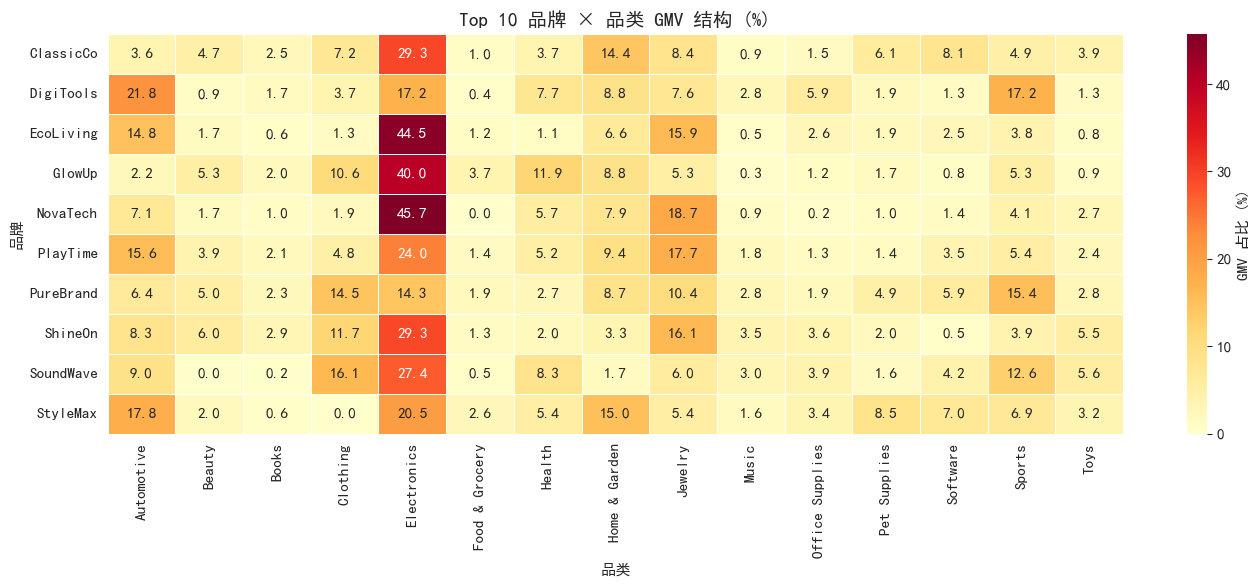

In [4]:
# 品牌 × 品类热力图（GMV 贡献）
brand_cat_gmv = completed.groupby(['brand', 'category'])['total_amount'].sum().unstack(fill_value=0)

# Top 10 品牌
top_brands = completed.groupby('brand')['total_amount'].sum().nlargest(10).index
brand_plot = brand_cat_gmv.loc[brand_cat_gmv.index.isin(top_brands)]
brand_plot_pct = brand_plot.div(brand_plot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(brand_plot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'GMV 占比 (%)'})
ax.set_title('Top 10 品牌 × 品类 GMV 结构 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('品类')
ax.set_ylabel('品牌')

plt.tight_layout()
plt.show()

## 5. 折扣对销量的真实影响

不同折扣力度下，销量有显著差异吗？

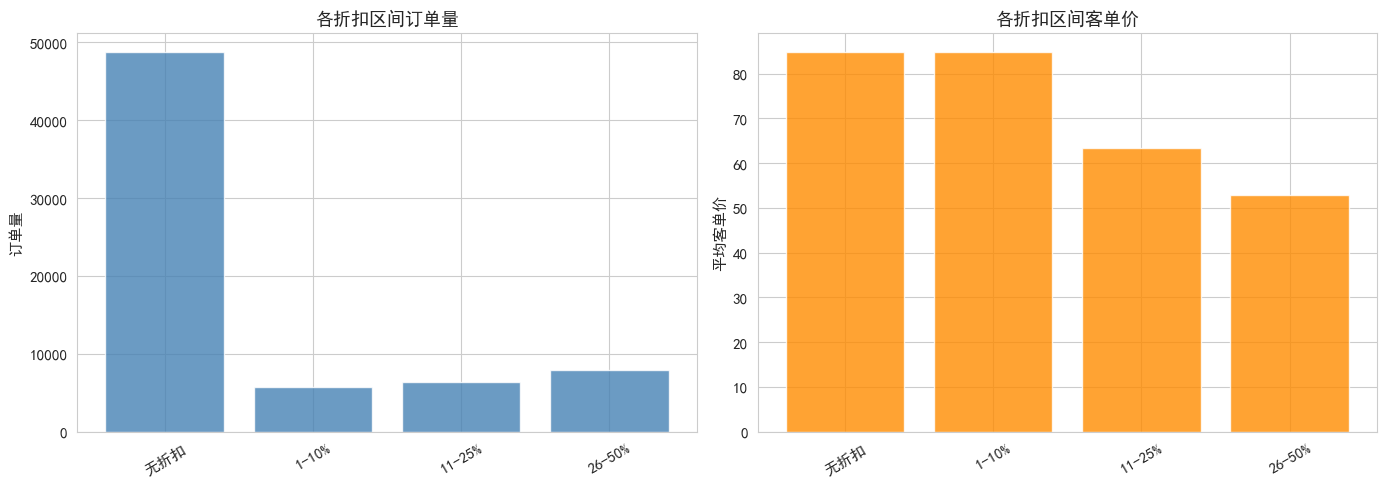

=== 折扣效果明细 ===
                orders  avg_quantity  avg_amount   total_gmv
discount_level                                              
无折扣              48808      1.466010   84.916651  4144611.91
1-10%             5657      1.469860   84.712915   479220.96
11-25%            6305      1.468041   63.371567   399557.73
26-50%            7930      1.473644   52.945453   419857.44


In [5]:
# 折扣力度 vs 销量
completed['discount_level'] = pd.cut(completed['discount_applied'],
                                      bins=[-1, 0, 10, 25, 51],
                                      labels=['无折扣', '1-10%', '11-25%', '26-50%'])

discount_effect = completed.groupby('discount_level').agg(
    orders=('transaction_id', 'nunique'),
    avg_quantity=('quantity', 'mean'),
    avg_amount=('total_amount', 'mean'),
    total_gmv=('total_amount', 'sum')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 折扣 vs 订单量
axes[0].bar(discount_effect.index, discount_effect['orders'], color='steelblue', alpha=0.8)
axes[0].set_title('各折扣区间订单量', fontsize=13, fontweight='bold')
axes[0].set_ylabel('订单量')
axes[0].tick_params(axis='x', rotation=30)

# 折扣 vs 客单价
axes[1].bar(discount_effect.index, discount_effect['avg_amount'], color='darkorange', alpha=0.8)
axes[1].set_title('各折扣区间客单价', fontsize=13, fontweight='bold')
axes[1].set_ylabel('平均客单价')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("=== 折扣效果明细 ===")
print(discount_effect.to_string())

**业务解读：**
- 如果中低折扣（1-10%）和大折扣（26-50%）的订单量相差不大 → 说明用户对折扣力度不敏感，那就不需要频繁打大折扣，用小额优惠券即可
- 如果折扣越大，客单价越低 → 说明折扣更多吸引了低价心理的用户，可能是低价值客群


## 6. 购物篮分析

"买了 A 的用户还买了什么？" 这是电商交叉销售的核心算法。

我们用 Apriori 算法挖掘高频商品组合，找出有意义的关联规则。

In [6]:
# 构建购物篮矩阵（transaction x product 的 one-hot 编码）
# 由于数据量可能很大，我们先用 Top 产品做示范
top_n = 50
top_products = completed.groupby('product_id')['transaction_id'].nunique().nlargest(top_n).index

# 构建 basket
basket = completed[completed['product_id'].isin(top_products)]
basket_matrix = basket.groupby(['transaction_id', 'product_id'])['quantity'].sum().unstack(fill_value=0)
basket_binary = (basket_matrix > 0).astype(int)

print(f"购物篮矩阵: {basket_binary.shape[0]} 笔交易 × {basket_binary.shape[1]} 个 Top {top_n} 商品")

# Apriori 挖掘频繁项集
frequent_itemsets = apriori(basket_binary, min_support=0.01, use_colnames=True)
print(f"\n频繁项集数 (support >= 1%): {len(frequent_itemsets)}")

# 生成关联规则
if len(frequent_itemsets) > 1:
    rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
    rules['antecedent_names'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)[:3]))
    rules['consequent_names'] = rules['consequents'].apply(lambda x: ', '.join(list(x)[:3]))

    # Top 10 按 lift 排序
    top_rules = rules.nlargest(10, 'lift')[
        ['antecedent_names', 'consequent_names', 'support', 'confidence', 'lift']
    ].round(3)

    print(f"\n=== Top 10 关联规则 (按 Lift 排序) ===")
    print(top_rules.to_string())

    # 可视化 Top 10 规则
    fig, ax = plt.subplots(figsize=(12, 5))
    y_labels = [f"{a} → {c}" for a, c in zip(top_rules['antecedent_names'], top_rules['consequent_names'])]
    ax.barh(range(len(top_rules)), top_rules['lift'], color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top_rules)))
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel('Lift (提升度)')
    ax.set_title('Top 10 关联规则 (按 Lift)', fontsize=13, fontweight='bold')
    ax.invert_yaxis()

    # 添加 confidence 标注
    for i, (lift, conf) in enumerate(zip(top_rules['lift'], top_rules['confidence'])):
        ax.text(lift + 0.02, i, f'Conf: {conf:.0%}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("频繁项集太少，无法生成规则。尝试降低 min_support 或扩大 top_n。")

购物篮矩阵: 4228 笔交易 × 50 个 Top 50 商品

频繁项集数 (support >= 1%): 50


TypeError: Column 'lift' has dtype object, cannot use method 'nlargest' with this dtype

**业务解读——关联规则三个指标：**
- **Support**（支持度）：规则涉及的商品组合占总交易的比例 → 越高说明这个组合越普遍
- **Confidence**（置信度）：买了 A 的用户中有多少比例也买了 B → 越高说明推荐成功率越高
- **Lift**（提升度）：买了 A 后买 B 的概率，是随机购买 B 概率的多少倍 → **Lift > 1 才有推荐价值**

**运营应用：**
- 高 Lift 组合 → 商品详情页"买了还买了"推荐
- 高 Confidence 组合 → 购物车凑单提醒
- 高 Support 组合 → 捆绑销售/套装策略


## 7. 商品评分与销量的关系

好的评分能带来更多销量吗？验证一下这个直觉。

In [ ]:
# 商品级别：评分 vs 销量
product_perf = completed.groupby('product_id').agg(
    total_sales=('total_amount', 'sum'),
    orders=('transaction_id', 'nunique'),
    avg_price=('unit_price', 'mean')
).reset_index().merge(products[['product_id', 'avg_rating', 'num_ratings', 'category']],
                       on='product_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散点：评分 vs 销量
axes[0].scatter(product_perf['avg_rating'], product_perf['orders'],
                alpha=0.3, c='steelblue', edgecolors='none')
axes[0].set_title('商品评分 vs 销量', fontsize=13, fontweight='bold')
axes[0].set_xlabel('平均评分')
axes[0].set_ylabel('销量 (订单数)')

# 按评分分组的平均销量
product_perf['rating_group'] = pd.cut(product_perf['avg_rating'],
                                       bins=[0, 2, 3, 3.5, 4, 4.5, 5.1],
                                       labels=['<=2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4.5-5'])
rating_sales = product_perf.groupby('rating_group')['orders'].mean()

axes[1].bar(range(len(rating_sales)), rating_sales.values, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(rating_sales)))
axes[1].set_xticklabels(rating_sales.index)
axes[1].set_title('各评分区间平均销量', fontsize=13, fontweight='bold')
axes[1].set_ylabel('平均订单数')

plt.tight_layout()
plt.show()

# 相关性
corr = product_perf[['avg_rating', 'orders', 'total_sales', 'avg_price']].corr()
print("=== 商品维度相关性矩阵 ===")
print(corr.round(3).to_string())

**业务解读：**
- 如果评分和销量的相关性很弱 → 说明用户购买决策受其他因素影响更大（价格、品牌、品类刚需度）
- 但低评分（< 3.0）商品的销量是否明显低于高评分商品？如果是，说明评分是"门槛"——用户不会买明显差评的商品
- 运营上，优先把 3.5 分以下商品的评价问题解决掉，ROI 最高


---

## 8.小结

| 分析维度 | 关键发现 | 运营策略 |
|----------|---------|---------|
| ABC 分层 | Top N 品类贡献 80% GMV | A 类保库存 + 供应链优化; C 类评估淘汰 |
| 品类矩阵 | 明星/走量/高端/长尾四象限 | 不同象限差异化运营 |
| 品牌结构 | 各品牌有品类侧重 | 品牌 × 品类联合营销 |
| 折扣效果 | 折扣力度对销量的弹性 | 小额优惠券节省预算，大折扣留给清仓 |
| 关联规则 | Top N 的高 Lift 组合 | 交叉销售：详情页推荐 + 凑单提醒 |
| 评分影响 | 评分是门槛，不是销量驱动力 | 优先处理 3.5 分以下商品的质量问题 |

**核心逻辑：** 商品分析的目标是"把对的货，在对的时间，推给对的人"。ABC 告诉你什么是"对的货"，关联规则告诉你"对的组合"，后续的 RFM 告诉你"对的人"。
